## Creating Kaggle-freindly environment

In [2]:
!pip install -q kagglehub

In [3]:
import os
import kagglehub
from google.colab import userdata
path = kagglehub.dataset_download("bricevergnou/spotify-recommendation")
print(path)

100%|██████████| 29.5k/29.5k [00:00<00:00, 28.3MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/bricevergnou/spotify-recommendation/versions/2


##Importing all essential Libraries

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

##Exploratory Data Analysis (EDA)

understanding the distribution of audio features and identify key patterns. checking for missing values, duplicates, and analyze the correlation between features like danceability, energy, and the user's liked status.

In [5]:
file_path = os.path.join(path, "data.csv")
df = pd.read_csv(file_path)

print(f"Shape:, {df.shape}\nColumns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
display(df.head())
print("\nSummary statistics:")
display(df.describe())


Shape:, (195, 14)
Columns: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'liked']

First 5 rows:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1



Summary statistics:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.636656,0.638431,5.497436,-9.481631,0.538462,0.148957,0.319093,0.192337,0.148455,0.493632,121.086174,213408.933333,3.912821,0.512821
std,0.216614,0.260096,3.415209,6.525086,0.499802,0.120414,0.320782,0.346226,0.105975,0.267695,28.084829,72152.392864,0.451332,0.501122
min,0.130000,0.002400,0.000000,-42.261000,0.000000,0.027800,0.000003,0.000000,0.033100,0.035300,60.171000,77203.000000,1.000000,0.000000
25%,0.462500,0.533500,2.000000,-9.962000,0.000000,0.056800,0.042200,0.000000,0.084000,0.269000,100.242000,178300.500000,4.000000,0.000000
50%,0.705000,0.659000,6.000000,-7.766000,1.000000,0.096200,0.213000,0.000008,0.105000,0.525000,124.896000,204000.000000,4.000000,1.000000
75%,0.799000,0.837500,8.000000,-5.829000,1.000000,0.230500,0.504000,0.097500,0.177000,0.717500,142.460500,242373.500000,4.000000,1.000000
max,0.946000,0.996000,11.000000,-2.336000,1.000000,0.540000,0.995000,0.969000,0.633000,0.980000,180.036000,655213.000000,5.000000,1.000000


In [6]:
print(f"missing values: {df.isnull().sum()}\n")
print(f"Duplicate values: {df.duplicated().sum()}")

missing values: danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
liked               0
dtype: int64

Duplicate values: 0


In [7]:
print("Target value")
print(df['liked'].value_counts())
print(df['liked'].value_counts(normalize=True)*100)

Target value
liked
1    100
0     95
Name: count, dtype: int64
liked
1    51.282051
0    48.717949
Name: proportion, dtype: float64


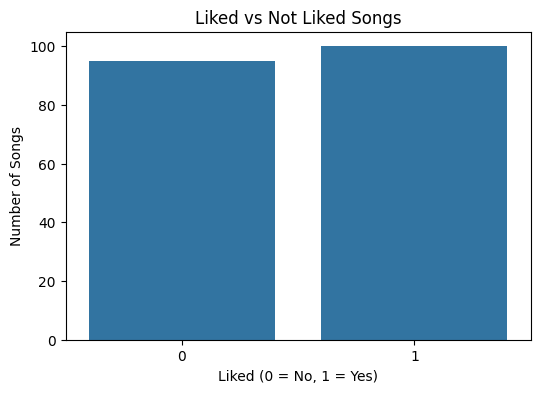

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="liked")
plt.title("Liked vs Not Liked Songs")
plt.xlabel("Liked (0 = No, 1 = Yes)")
plt.ylabel("Number of Songs")
plt.show()

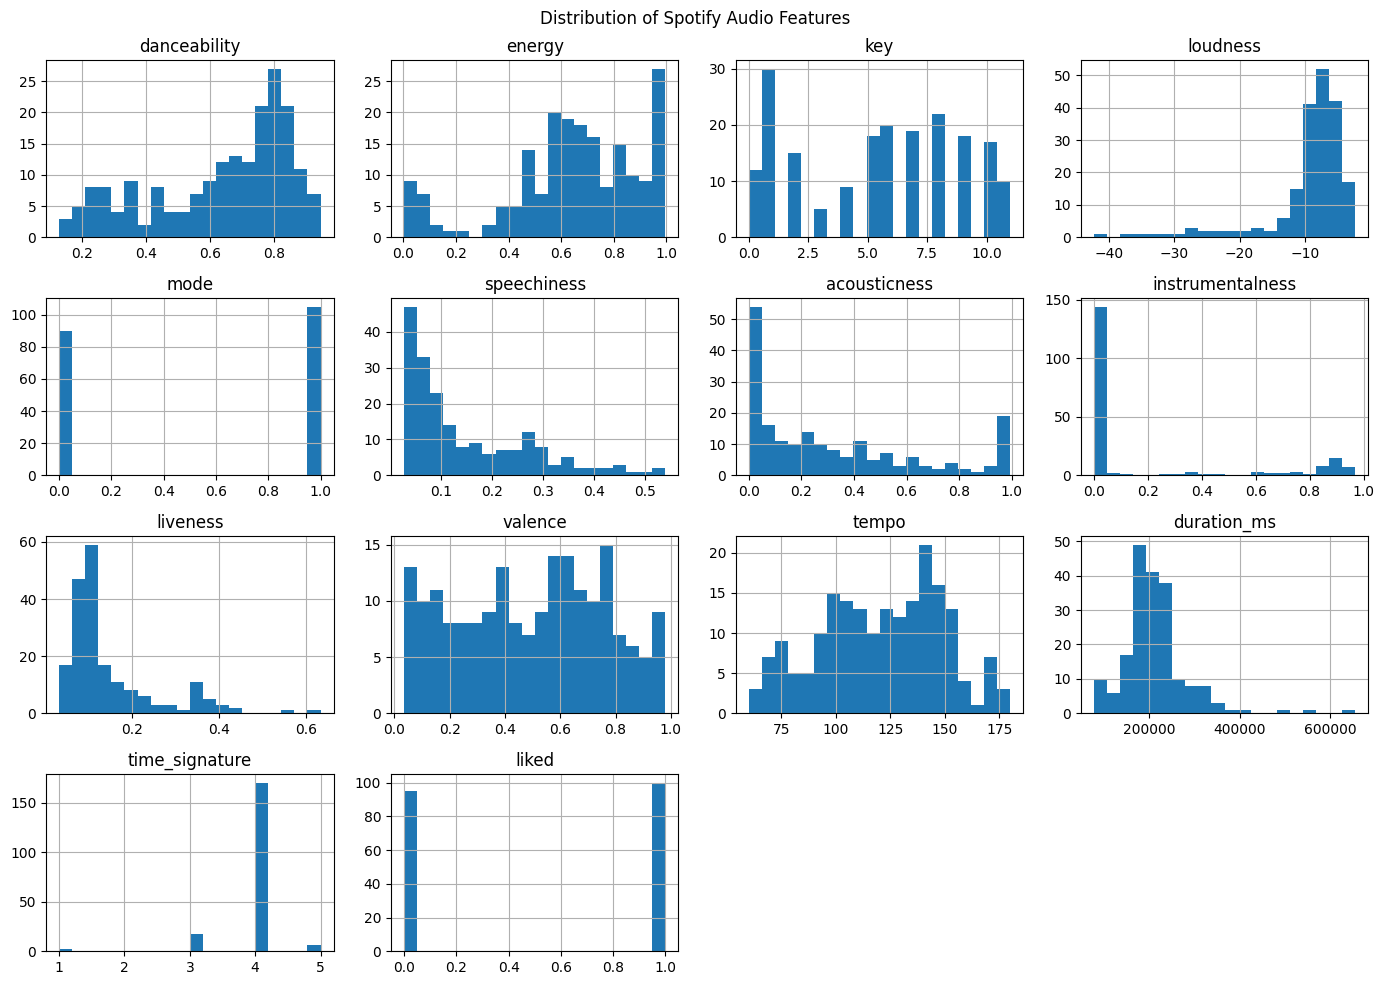

In [9]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribution of Spotify Audio Features")
plt.tight_layout()
plt.show()

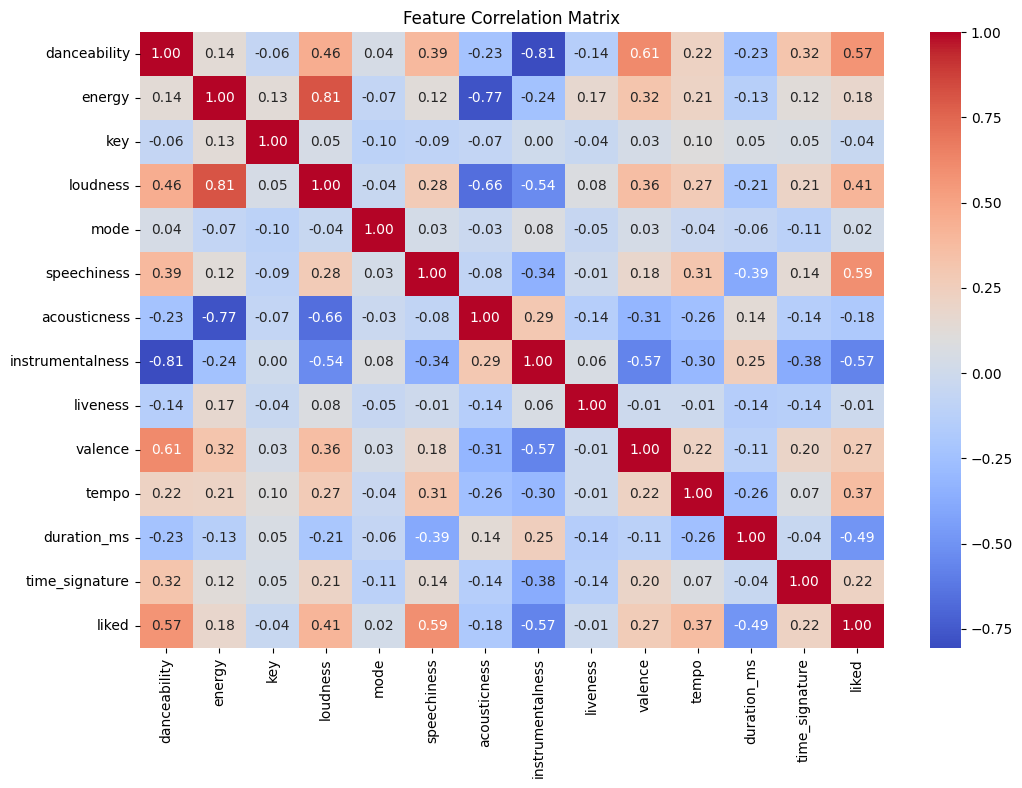

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

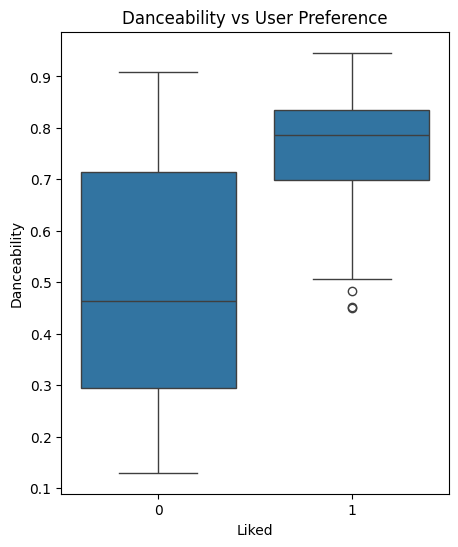

In [11]:
plt.figure(figsize=(5, 6))
sns.boxplot(data=df, x="liked", y="danceability")
plt.title("Danceability vs User Preference")
plt.xlabel("Liked")
plt.ylabel("Danceability")
plt.show()

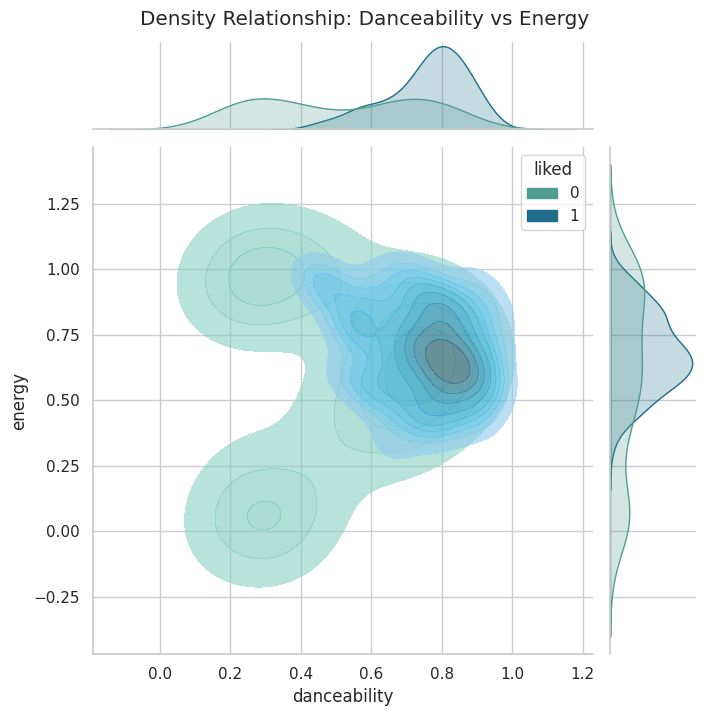

In [12]:
sns.set_theme(style='whitegrid', palette='magma')
plt.rcParams['figure.dpi'] = 100

g = sns.jointplot(data=df, x='danceability', y='energy', hue='liked',
                  kind='kde', fill=True, alpha=0.6, height=7, palette='crest')
g.fig.suptitle('Density Relationship: Danceability vs Energy', y=1.02)
plt.show()

##Data Preprocessing

To prepare the data for machine learning, splitting the dataset into training and testing sets. also applyyig feature scaling using StandardScaler to ensure that features with different magnitudes are treated equally by our models.

In [13]:
X = df.drop('liked', axis=1)
Y = df['liked']
print(f"Features shape: {X.shape}\nTarget shape: {Y.shape}")

Features shape: (195, 13)
Target shape: (195,)


In [14]:
X_train, X_test, Y_train,Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nY_train shape: {Y_train.shape}\nY_test shape: {Y_test.shape}")

X_train shape: (156, 13)
X_test shape: (39, 13)
Y_train shape: (156,)
Y_test shape: (39,)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled training features:", X_train_scaled.shape)
print("Shape of scaled test features:", X_test_scaled.shape)

Shape of scaled training features: (156, 13)
Shape of scaled test features: (39, 13)


##Model Training and Hyperparameter Tuning

training multiple classification algorithms simantaniously, including Logistic Regrssion, Decision Tree, Random Forest, Gradient Boosting, Sum Vector and KNN. Also using grid search to optimize model performance based on the F1-score.

In [16]:
pipeline_lr = Pipeline([('classifier', LogisticRegression(random_state=42, solver='liblinear'))])
pipeline_dt = Pipeline([('classifier', DecisionTreeClassifier(random_state=42))])
pipeline_rf = Pipeline([('classifier', RandomForestClassifier(random_state=42))])
pipeline_gb = Pipeline([('classifier', GradientBoostingClassifier(random_state=42))])
pipeline_svc = Pipeline([('classifier', SVC(random_state=42))])
pipeline_knn = Pipeline([('classifier', KNeighborsClassifier())])

param_grid_lr = {'classifier__C': [0.1, 1, 10]}
param_grid_dt = {'classifier__max_depth': [None, 10, 20, 30]}
param_grid_rf = {'classifier__n_estimators': [50, 100, 200],
                 'classifier__max_depth': [None, 10, 20]}
param_grid_gb = {'classifier__n_estimators': [50, 100, 200],
                 'classifier__learning_rate': [0.01, 0.1, 0.2]}
param_grid_svc = {'classifier__C': [0.1, 1, 10],
                  'classifier__kernel': ['linear', 'rbf']}
param_grid_knn = {'classifier__n_neighbors': [3, 5, 7, 9]}

models_with_params = {
    'Logistic Regression': (pipeline_lr, param_grid_lr),
    'Decision Tree': (pipeline_dt, param_grid_dt),
    'Random Forest': (pipeline_rf, param_grid_rf),
    'Gradient Boosting': (pipeline_gb, param_grid_gb),
    'SVC': (pipeline_svc, param_grid_svc),
    'K-Nearest Neighbors': (pipeline_knn, param_grid_knn)}

results = {}
best_models = {}

for name, (pipeline, param_grid) in models_with_params.items():
    print(f"\nTraining and Tuning {name}")
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
    grid_search.fit(X_train_scaled, Y_train)

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    Y_pred = best_model.predict(X_test_scaled)

    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)

    results[name] = {
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1}

print("\nModel Performance Summary with Hyperparameter Tuning")
performance_df = pd.DataFrame(results).T
display(performance_df.sort_values(by='F1-Score', ascending=False))


Training and Tuning Logistic Regression

Training and Tuning Decision Tree

Training and Tuning Random Forest

Training and Tuning Gradient Boosting

Training and Tuning SVC

Training and Tuning K-Nearest Neighbors

Model Performance Summary with Hyperparameter Tuning


,Best Params,Accuracy,Precision,Recall,F1-Score
Random Forest,"{'classifier__max_depth': None, 'classifier__n...",0.948718,0.95,0.95,0.95
Gradient Boosting,"{'classifier__learning_rate': 0.01, 'classifie...",0.923077,1.0,0.85,0.918919
Logistic Regression,{'classifier__C': 0.1},0.871795,0.857143,0.9,0.878049
SVC,"{'classifier__C': 1, 'classifier__kernel': 'rbf'}",0.871795,0.857143,0.9,0.878049
K-Nearest Neighbors,{'classifier__n_neighbors': 5},0.846154,0.85,0.85,0.85
Decision Tree,{'classifier__max_depth': None},0.846154,0.9375,0.75,0.833333


## BEST Model

In [17]:
best_model_name = performance_df.sort_values(by='F1-Score', ascending=False).index[0]
best_model_pipeline = best_models[best_model_name]

Y_pred_best = best_model_pipeline.predict(X_test_scaled)

print(f"\nAnalysis for the Best Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_best))


Analysis for the Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      0.95      0.95        20

    accuracy                           0.95        39
   macro avg       0.95      0.95      0.95        39
weighted avg       0.95      0.95      0.95        39


Confusion Matrix:
[[18  1]
 [ 1 19]]


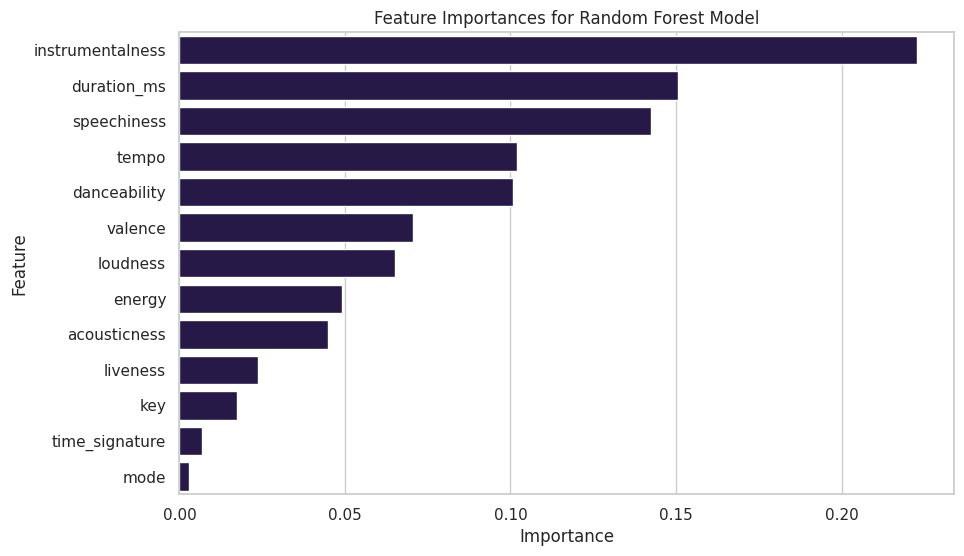

In [18]:
if hasattr(best_model_pipeline.named_steps['classifier'], 'feature_importances_'):
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
    features_df = features_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=features_df)
    plt.title('Feature Importances for Random Forest Model')
    plt.show()
else:
    print("Feature importances are not available for the best model.")

/tmp/ipykernel_393/1650267320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='liked', y='instrumentalness', split=True,


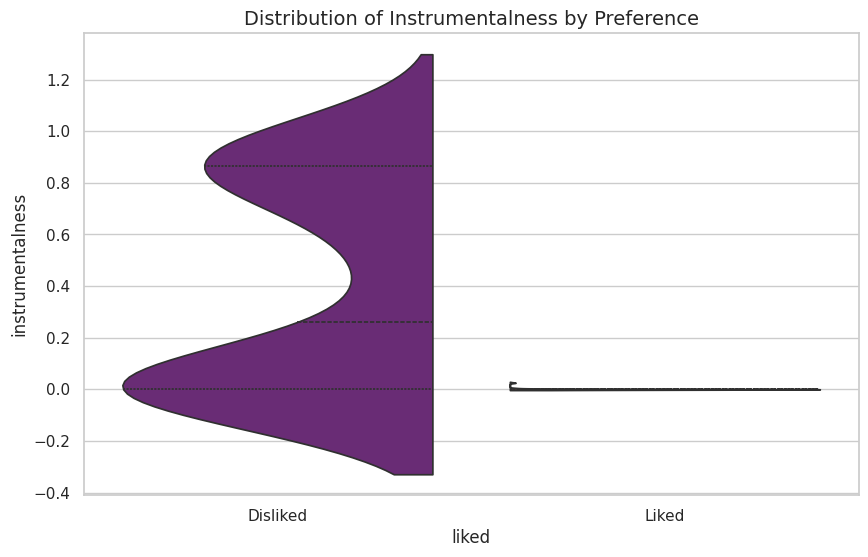

In [24]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='liked', y='instrumentalness', split=True,
               inner='quart', palette='magma')
plt.title('Distribution of Instrumentalness by Preference', fontsize=14)
plt.xticks([0, 1], ['Disliked', 'Liked'])
plt.show()

## Generate System Recommendations
system to generate song recommendations using the best model to predict liked songs for new or unrated tracks or identifying similar songs to those already liked by a user based on the model's output.


In [28]:
unseen_songs = df.drop(index=X_test.index)
unseen_songs = unseen_songs.drop(index=X_train.index)

print(f"Number of unseen songs: {unseen_songs.shape[0]}")

display(unseen_songs.head())

Number of unseen songs: 0


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked


**Reasoning**:
filtering the original DataFrame to select only the songs that the user did not like (liked == 0). Then extracting their features, scale them using the previously fitted scaler, and use the best-performing model to predict the 'liked' status for these candidate songs.



In [29]:
candidate_songs = df[df['liked'] == 0].copy()

X_candidate = candidate_songs.drop('liked', axis=1)
X_candidate_scaled = scaler.transform(X_candidate)
predictions = best_model_pipeline.predict(X_candidate_scaled)
candidate_songs['predicted_liked'] = predictions
recommended_songs = candidate_songs[candidate_songs['predicted_liked'] == 1]

print(f"The system's recommendations of features of a song for getting 'like' ")
display(recommended_songs.head())

The system's recommendations of features of a song for getting 'like' 


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked,predicted_liked
145,0.651,0.639,3,-7.836,0,0.0583,0.019,0.0,0.0522,0.758,157.738,247440,4,0,1


This list represents songs that the model believes the user would enjoy, despite their previous explicit dislike. These songs can be presented to the user as new recommendations. Further filtering or diversification techniques could be applied to this list to enhance the recommendation experience.

##Models performance Visualization

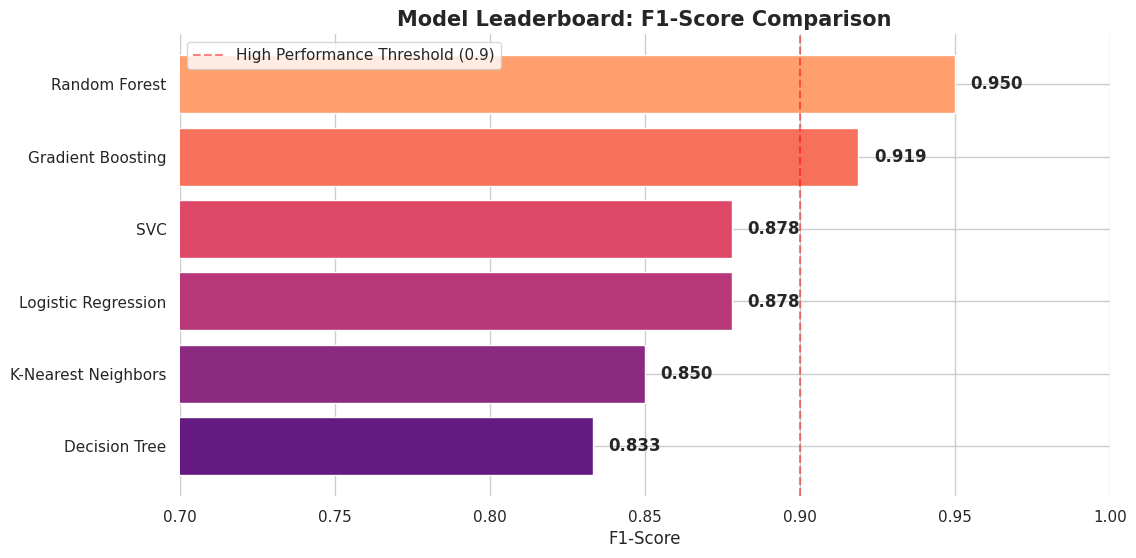

In [22]:
plt.figure(figsize=(12, 6))
performance_sorted = performance_df.sort_values(by='F1-Score', ascending=True)
colors = plt.cm.magma(np.linspace(0.3, 0.8, len(performance_sorted)))

bars = plt.barh(performance_sorted.index, performance_sorted['F1-Score'], color=colors)
plt.axvline(x=0.9, color='red', linestyle='--', alpha=0.5, label='High Performance Threshold (0.9)')

plt.title('Model Leaderboard: F1-Score Comparison', fontsize=15, fontweight='bold')
plt.xlabel('F1-Score')
plt.xlim(0.7, 1.0)
plt.legend()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.show()

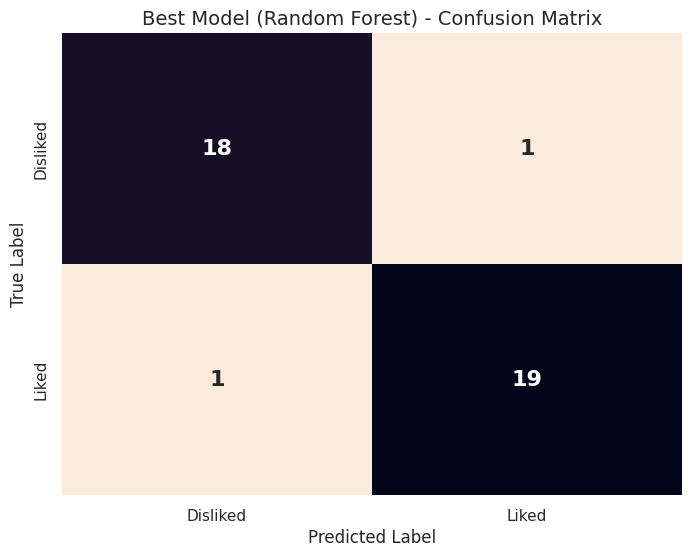

In [23]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(Y_test, Y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
            xticklabels=['Disliked', 'Liked'],
            yticklabels=['Disliked', 'Liked'],
            cbar=False, annot_kws={'size': 16, 'weight': 'bold'})

plt.title('Best Model (Random Forest) - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()